<a href="https://colab.research.google.com/github/RiteshRajput07/RItesh_Projects/blob/main/fraud_detection_in_banking_transaction_data_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('/Fraud.csv')

# New Section

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3277114 entries, 0 to 3277113
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 275.0+ MB


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df.shape

(3277114, 11)

In [ ]:
df.size

36048254

In [ ]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3277109,251,PAYMENT,38762.83,C774795622,75123.0,36360.17,M1083742946,0.00,0.00,0.0,0.0
3277110,251,CASH_OUT,136877.67,C1191158286,205066.0,68188.33,C2061788754,230441.35,367319.02,0.0,0.0
3277111,251,PAYMENT,71892.07,C587528392,10108.0,0.00,M2122061967,0.00,0.00,0.0,0.0
3277112,251,CASH_OUT,409135.30,C2058863144,107731.0,0.00,C1829162223,0.00,409135.30,0.0,0.0
3277113,251,CASH_OUT,185077.27,C1105,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.sample(15)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1050270,95,TRANSFER,306606.15,C387471736,0.00,0.00,C401148995,4044805.26,4351411.41,0.0,0.0
1362560,138,TRANSFER,252046.72,C1712078849,12431.81,0.00,C615890600,983393.94,1217488.55,0.0,0.0
1464573,140,CASH_OUT,104642.03,C757623954,0.00,0.00,C805281798,906310.52,1010952.55,0.0,0.0
2964839,231,PAYMENT,72.78,C2016508408,0.00,0.00,M1093663412,0.00,0.00,0.0,0.0
1687789,159,TRANSFER,559175.61,C1742319287,30561.00,0.00,C272164079,608133.83,1167309.44,0.0,0.0
1161188,131,CASH_OUT,70138.49,C1050944423,26921.00,0.00,C844001916,0.00,70138.49,0.0,0.0
2182231,185,CASH_IN,195199.25,C2133075085,21168525.05,21363724.30,C337367078,405501.70,210302.45,0.0,0.0
2180759,185,CASH_OUT,183388.49,C2045189096,70705.00,0.00,C480686292,101837.01,285225.51,0.0,0.0
754160,38,CASH_IN,85677.87,C1298190732,9747540.72,9833218.59,C728824267,191512.68,105834.81,0.0,0.0
3180751,239,PAYMENT,4532.21,C1522464631,432788.00,428255.79,M1242043668,0.00,0.00,0.0,0.0


In [ ]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [ ]:
#Sets the pandas display option to format floating-point numbers with four decimal places
pd.set_option('display.float_format', lambda x: '%0.4f' % x)

In [ ]:
round(df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig','oldbalanceDest',
                'newbalanceDest',]].describe().T,
      2)

,count,mean,std,min,25%,50%,75%,max
step,3277114.0000,134.0000,79.7800,1.0000,40.0000,157.0000,203.0000,251.0000
amount,3277114.0000,158044.2900,269533.3900,0.0000,12658.1800,76035.0800,211316.8800,10000000.0000
oldbalanceOrg,3277113.0000,841550.0500,2904774.3900,0.0000,0.0000,14565.0000,112448.0000,38939424.0300
newbalanceOrig,3277113.0000,863045.1300,2941126.5800,0.0000,0.0000,0.0000,151979.2100,38946233.0200
oldbalanceDest,3277113.0000,994965.6000,2301730.0000,0.0000,0.0000,136990.0000,943560.5300,42655769.2000
newbalanceDest,3277113.0000,1101129.7100,2383192.0600,0.0000,0.0000,222908.6800,1126050.2700,42854299.6400


In [ ]:
df.loc[:, ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']].corr()



,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.0000,-0.0067,-0.0087,-0.0083,0.0033,-0.0063,-0.0034,0.0009
amount,-0.0067,1.0000,0.0060,0.0012,0.2151,0.3112,0.1283,0.0087
oldbalanceOrg,-0.0087,0.0060,1.0000,0.9991,0.0936,0.0642,0.0057,0.0006
newbalanceOrig,-0.0083,0.0012,0.9991,1.0000,0.0957,0.0640,-0.0078,0.0006
oldbalanceDest,0.0033,0.2151,0.0936,0.0957,1.0000,0.9866,-0.0067,-0.0003
newbalanceDest,-0.0063,0.3112,0.0642,0.0640,0.9866,1.0000,0.0006,-0.0004
isFraud,-0.0034,0.1283,0.0057,-0.0078,-0.0067,0.0006,1.0000,0.0265
isFlaggedFraud,0.0009,0.0087,0.0006,0.0006,-0.0003,-0.0004,0.0265,1.0000


In [ ]:
df.query("amount == 0")


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736447,212,CASH_OUT,0.0000,C1510987794,0.0000,0.0000,C1696624817,0.0000,0.0000,1.0000,0.0000
3247298,250,CASH_OUT,0.0000,C521393327,0.0000,0.0000,C480398193,0.0000,0.0000,1.0000,0.0000


In [ ]:
df.query("isFlaggedFraud == 1")


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.0800,C728984460,4953893.0800,4953893.0800,C639921569,0.0000,0.0000,1.0000,1.0000
3247297,250,TRANSFER,1343002.0800,C1100582606,1343002.0800,1343002.0800,C1147517658,0.0000,0.0000,1.0000,1.0000


In [ ]:
df.query("amount == oldbalanceOrg and isFraud == 1")


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1.0000,0.0000
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1.0000,0.0000
251,1,TRANSFER,2806.0000,C1420196421,2806.0000,0.0000,C972765878,0.0000,0.0000,1.0000,0.0000
252,1,CASH_OUT,2806.0000,C2101527076,2806.0000,0.0000,C1007251739,26202.0000,0.0000,1.0000,0.0000
680,1,TRANSFER,20128.0000,C137533655,20128.0000,0.0000,C1848415041,0.0000,0.0000,1.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
3267055,251,CASH_OUT,82112.7400,C1458675534,82112.7400,0.0000,C1324801555,7968.1500,90080.8900,1.0000,0.0000
3271320,251,TRANSFER,609416.2100,C145364,609416.2100,0.0000,C312230940,0.0000,0.0000,1.0000,0.0000
3271321,251,CASH_OUT,609416.2100,C859655738,609416.2100,0.0000,C901559615,4316293.8700,4925710.0800,1.0000,0.0000
3273907,251,TRANSFER,2693520.6100,C2141912199,2693520.6100,0.0000,C598875397,0.0000,0.0000,1.0000,0.0000


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
df[df.duplicated()]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0.0000,3274262
1.0000,2851


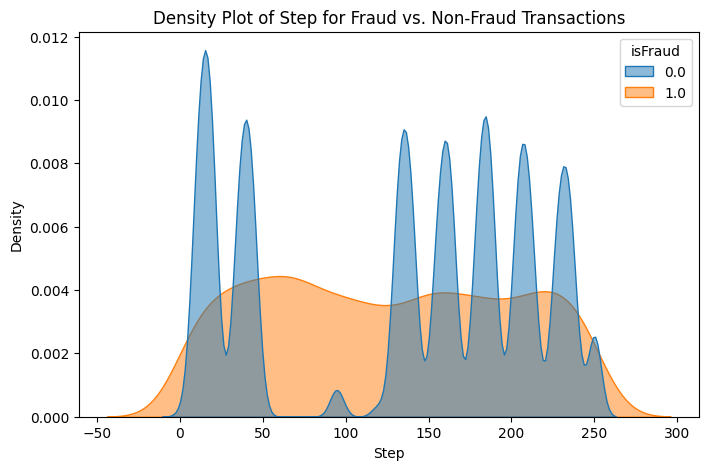

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='step', hue='isFraud', fill=True, common_norm=False, alpha=0.5)
plt.title("Density Plot of Step for Fraud vs. Non-Fraud Transactions")
plt.xlabel("Step")
plt.ylabel("Density")
plt.show()



<ipython-input-30-26ded133aadd>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='isFraud', y='amount', data=df, palette='coolwarm')


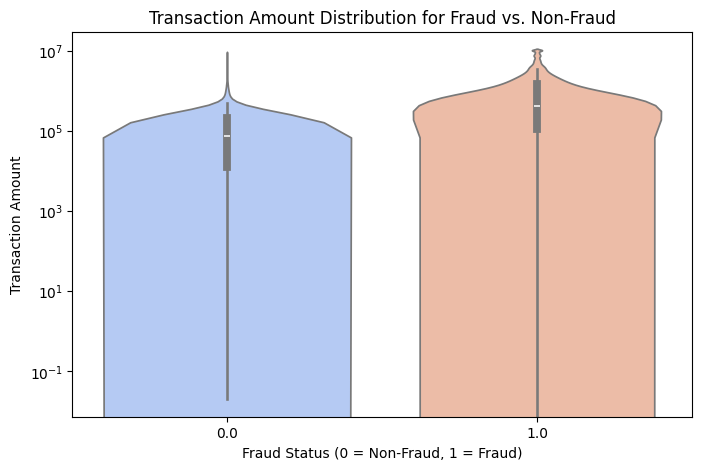

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='isFraud', y='amount', data=df, palette='coolwarm')
plt.title("Transaction Amount Distribution for Fraud vs. Non-Fraud")
plt.xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.yscale("log")  # log scale for better visualization if values vary widely
plt.show()

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0.0000,3274262
1.0000,2851


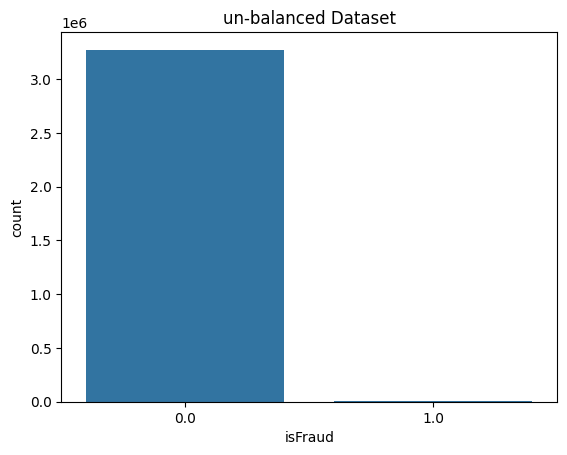

In [ ]:
sns.countplot(x=df['isFraud'])
plt.title("un-balanced Dataset")
plt.show()

<ipython-input-33-b98fe41b27f3>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['isFraud'].value_counts().index,


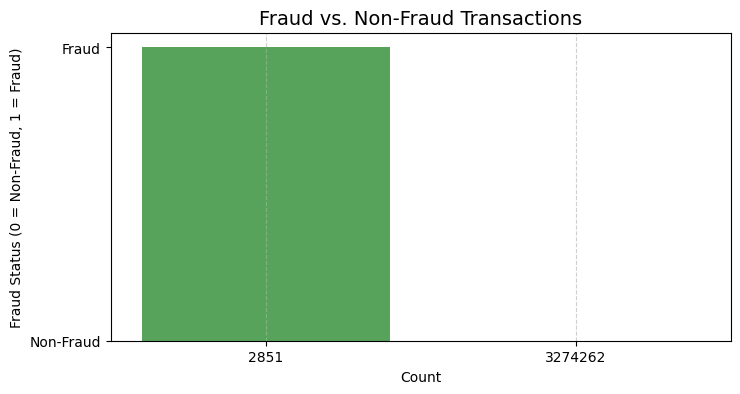

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(y=df['isFraud'].value_counts().index,
            x=df['isFraud'].value_counts().values,
            palette=['#4CAF50', '#F44336'])  # Green for Non-Fraud, Red for Fraud
plt.title("Fraud vs. Non-Fraud Transactions", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.yticks([0, 1], labels=["Non-Fraud", "Fraud"])
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

<ipython-input-34-0e5b3b965b77>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="type", y="isFraud", kind="box", palette="coolwarm")


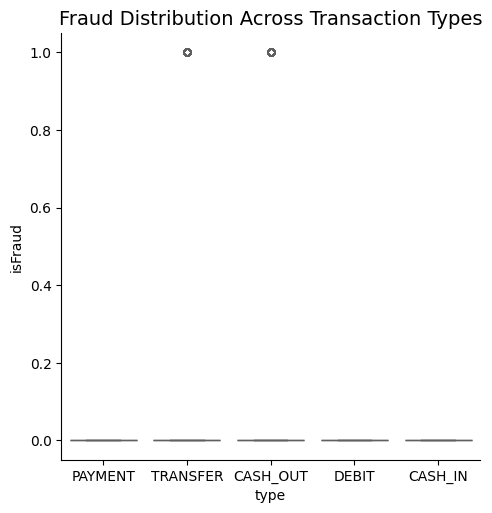

In [ ]:
# Create a box plot with custom colors
sns.catplot(data=df, x="type", y="isFraud", kind="box", palette="coolwarm")

# Set title for better understanding
plt.title("Fraud Distribution Across Transaction Types", fontsize=14)
plt.show()

In [ ]:
df.loc[(df['type']=="CASH_OUT") & (df['isFraud']==1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1.0000,0.0000
252,1,CASH_OUT,2806.0000,C2101527076,2806.0000,0.0000,C1007251739,26202.0000,0.0000,1.0000,0.0000
681,1,CASH_OUT,20128.0000,C1118430673,20128.0000,0.0000,C339924917,6268.0000,12145.8500,1.0000,0.0000
724,1,CASH_OUT,416001.3300,C749981943,0.0000,0.0000,C667346055,102.0000,9291619.6200,1.0000,0.0000
970,1,CASH_OUT,1277212.7700,C467632528,1277212.7700,0.0000,C716083600,0.0000,2444985.1900,1.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
3251863,251,CASH_OUT,8276235.5000,C1880773458,8276235.5000,0.0000,C2102473649,190006.6900,8466242.1900,1.0000,0.0000
3257999,251,CASH_OUT,345425.5700,C1514359401,345425.5700,0.0000,C648222182,208488.9000,553914.4700,1.0000,0.0000
3267055,251,CASH_OUT,82112.7400,C1458675534,82112.7400,0.0000,C1324801555,7968.1500,90080.8900,1.0000,0.0000
3271321,251,CASH_OUT,609416.2100,C859655738,609416.2100,0.0000,C901559615,4316293.8700,4925710.0800,1.0000,0.0000


In [ ]:
df.loc[(df['type']=="TRANSFER") & (df['isFraud']==1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1.0000,0.0000
251,1,TRANSFER,2806.0000,C1420196421,2806.0000,0.0000,C972765878,0.0000,0.0000,1.0000,0.0000
680,1,TRANSFER,20128.0000,C137533655,20128.0000,0.0000,C1848415041,0.0000,0.0000,1.0000,0.0000
969,1,TRANSFER,1277212.7700,C1334405552,1277212.7700,0.0000,C431687661,0.0000,0.0000,1.0000,0.0000
1115,1,TRANSFER,35063.6300,C1364127192,35063.6300,0.0000,C1136419747,0.0000,0.0000,1.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
3251862,251,TRANSFER,8276235.5000,C1112360108,8276235.5000,0.0000,C1241281307,0.0000,0.0000,1.0000,0.0000
3257998,251,TRANSFER,345425.5700,C1397090856,345425.5700,0.0000,C2119085039,0.0000,0.0000,1.0000,0.0000
3267054,251,TRANSFER,82112.7400,C106888185,82112.7400,0.0000,C299512906,0.0000,0.0000,1.0000,0.0000
3271320,251,TRANSFER,609416.2100,C145364,609416.2100,0.0000,C312230940,0.0000,0.0000,1.0000,0.0000


In [ ]:
!pip install squarify
#can install this module if not availble in your pc

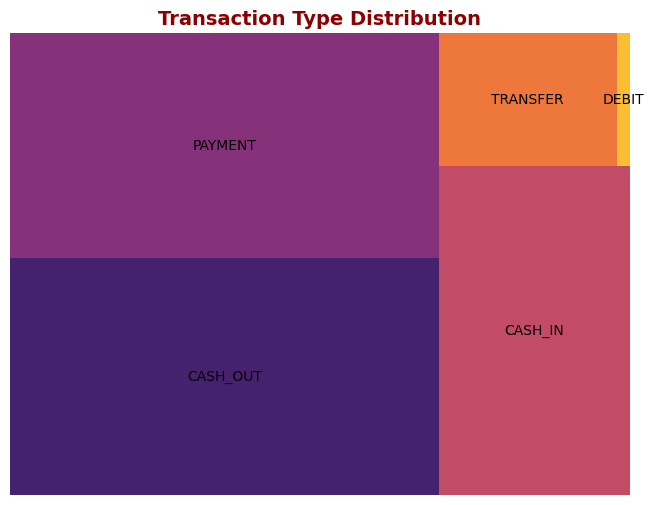

In [ ]:
import squarify
# Count occurrences of each transaction type
type_counts = df['type'].value_counts()

# Define an aggressive color palette (e.g., "Reds", "Inferno", or "Dark2")
colors = sns.color_palette("inferno", len(type_counts))

# Create treemap
plt.figure(figsize=(8, 6))
squarify.plot(sizes=type_counts.values, label=type_counts.index, alpha=0.9, color=colors)

# Add title
plt.title("Transaction Type Distribution", fontsize=14, fontweight="bold", color="darkred")

# Remove axes for a cleaner look
plt.axis("off")

plt.show()

In [ ]:
# using iqr method in "step" feature...

per25=df['step'].quantile(0.25)
per75=df['step'].quantile(0.75)
iqr=per75-per25
up_limit=per75+(1.5*iqr)
low_limit=per25-(1.5*iqr)
print("upper limit :- ",up_limit)
print("upper limit :- ",low_limit)

upper limit :-  447.5
upper limit :-  -204.5


In [ ]:
df[df["step"]>603]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud


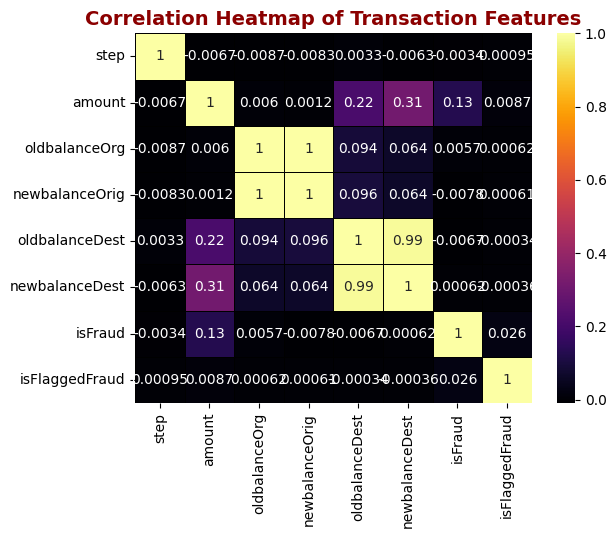

In [ ]:
sns.heatmap(df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
                'newbalanceDest', 'isFraud', 'isFlaggedFraud']].corr(),
            annot=True, cmap="inferno", linewidths=0.5, linecolor="black")

plt.title("Correlation Heatmap of Transaction Features", fontsize=14, fontweight="bold", color="darkred")
plt.show()


In [ ]:
# df.corr()["isFraud"]
df.corr(numeric_only=True)["isFraud"]


,isFraud
step,-0.0034
amount,0.1283
oldbalanceOrg,0.0057
newbalanceOrig,-0.0078
oldbalanceDest,-0.0067
newbalanceDest,0.0006
isFraud,1.0000
isFlaggedFraud,0.0265


In [ ]:
# function which returns un_important features ( only numeric ).

def correlation(dataset,threshold):

    """
    used to store un_important column names
    and set() type stores only unique values
    so, that no duplicated column name will store.
    """
    column_corr=set()

    # storing correlation matrix
    corr_matrix=dataset.corr()

    for i in range (len(corr_matrix.columns)):
        for j in range (i):

            # comparing corr. values with threshold
            if corr_matrix.iloc[i,j]>threshold:

                # if true, then fateching column name
                colname=corr_matrix.columns[i]

                # adding column name to column_corr variable.
                column_corr.add(colname)
    return column_corr


In [ ]:
# # calling ... with threshold value 0.9
# corr_matrix = df.corr(numeric_only=True)

# correlated_features=correlation(df,0.9)

# Calculate correlation matrix with numeric_only=True
corr_matrix = df.corr(numeric_only=True)

# Find correlated features based on a threshold of 0.9
correlated_features = correlation(corr_matrix, 0.9)

# Define function to find correlated features
def correlation(corr_matrix, threshold):
    correlated_features = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                correlated_features.add(colname)
    return correlated_features


In [ ]:
# total number of un_important features
len(set(correlated_features))

2

In [ ]:
# name of these columns ( independent features)
correlated_features

{'newbalanceDest', 'newbalanceOrig'}

In [ ]:
# Removing these features from DataFrame.

df=df.drop(correlated_features,axis=1)

In [ ]:
# After removing ...
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,nameDest,oldbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,M1979787155,0.0000,0.0000,0.0000
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,M2044282225,0.0000,0.0000,0.0000
2,1,TRANSFER,181.0000,C1305486145,181.0000,C553264065,0.0000,1.0000,0.0000
3,1,CASH_OUT,181.0000,C840083671,181.0000,C38997010,21182.0000,1.0000,0.0000
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,M1230701703,0.0000,0.0000,0.0000


In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
"""
threshold=0  means feature having only 1 value ( no variation)
threshold=1 means feature having 2 different values ( small variation)
etc
"""
Var_Thresh=VarianceThreshold(threshold=0)
Var_Thresh.fit(df[['step','amount','oldbalanceOrg','oldbalanceDest','isFlaggedFraud']])
Var_Thresh.get_support()

array([ True,  True,  True,  True,  True])

In [ ]:
# when threshold=1

Var_Thresh=VarianceThreshold(threshold=1)
Var_Thresh.fit(df[['step','amount','oldbalanceOrg','oldbalanceDest','isFlaggedFraud']])
Var_Thresh.get_support()

array([ True,  True,  True,  True, False])

In [ ]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
nameDest,object
oldbalanceDest,float64
isFraud,float64
isFlaggedFraud,float64


In [ ]:
print(" type having these unique values :- \n",df["type"].unique())
print("\n\n nameOrig having these unique values :- \n",df["nameOrig"].unique())
print("\n\n nameDest having these unique values :- \n",df["nameDest"].unique())

 type having these unique values :- 
 ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


 nameOrig having these unique values :- 
 ['C1231006815' 'C1666544295' 'C1305486145' ... 'C587528392' 'C2058863144'
 'C1105']


 nameDest having these unique values :- 
 ['M1979787155' 'M2044282225' 'C553264065' ... 'M2122061967' 'C1829162223'
 nan]


In [ ]:
df['nameOrig'].value_counts()

,count
nameOrig,
C1677795071,3
C1530544995,3
C400299098,3
C1999539787,3
C2082758300,2
...,...
C898013797,1
C2010009955,1
C945842322,1


In [ ]:
df['nameDest'].value_counts()

,count
nameDest,
C1286084959,104
C985934102,103
C665576141,100
C248609774,95
C1590550415,94
...,...
M1571571917,1
M537422016,1
M977984599,1


In [ ]:
df=df.drop({'nameOrig','nameDest'},axis=1)

In [ ]:
df.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,170136.0000,0.0000,0.0000,0.0000
1,1,PAYMENT,1864.2800,21249.0000,0.0000,0.0000,0.0000
2,1,TRANSFER,181.0000,181.0000,0.0000,1.0000,0.0000
3,1,CASH_OUT,181.0000,181.0000,21182.0000,1.0000,0.0000
4,1,PAYMENT,11668.1400,41554.0000,0.0000,0.0000,0.0000


In [ ]:
df["type"].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [ ]:
df["type"].value_counts()

,count
type,
CASH_OUT,1164385
PAYMENT,1102390
CASH_IN,718645
TRANSFER,271100
DEBIT,20594


In [ ]:
df['type']=df['type'].map({'CASH_OUT':5, 'PAYMENT':4,'CASH_IN':3,'TRANSFER':2,'DEBIT':1})

In [ ]:
df.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud
0,1,4,9839.6400,170136.0000,0.0000,0.0000,0.0000
1,1,4,1864.2800,21249.0000,0.0000,0.0000,0.0000
2,1,2,181.0000,181.0000,0.0000,1.0000,0.0000
3,1,5,181.0000,181.0000,21182.0000,1.0000,0.0000
4,1,4,11668.1400,41554.0000,0.0000,0.0000,0.0000


In [ ]:
df["type"].unique()


array([4, 2, 5, 1, 3])

In [ ]:
df["type"].value_counts()


,count
type,
5,1164385
4,1102390
3,718645
2,271100
1,20594


In [ ]:
df["isFraud"].value_counts()

,count
isFraud,
0.0000,3274262
1.0000,2851


In [ ]:
"""
Creating 2 new DataFrame ,
one contain fraud transaction
and another one contain genuine transaction
"""
normal_transaction=df[df['isFraud']==0]
fraud_transaction=df[df['isFraud']==1]

In [ ]:
normal_transaction.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud
0,1,4,9839.6400,170136.0000,0.0000,0.0000,0.0000
1,1,4,1864.2800,21249.0000,0.0000,0.0000,0.0000
4,1,4,11668.1400,41554.0000,0.0000,0.0000,0.0000
5,1,4,7817.7100,53860.0000,0.0000,0.0000,0.0000
6,1,4,7107.7700,183195.0000,0.0000,0.0000,0.0000


In [ ]:
fraud_transaction.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud
2,1,2,181.0000,181.0000,0.0000,1.0000,0.0000
3,1,5,181.0000,181.0000,21182.0000,1.0000,0.0000
251,1,2,2806.0000,2806.0000,0.0000,1.0000,0.0000
252,1,5,2806.0000,2806.0000,26202.0000,1.0000,0.0000
680,1,2,20128.0000,20128.0000,0.0000,1.0000,0.0000


In [ ]:
print(normal_transaction.shape)
print(fraud_transaction.shape)

(3274262, 7)
(2851, 7)


In [ ]:
# taking random 8213 records from normal_transaction

normal_transaction=normal_transaction.sample(n=9500)

In [ ]:
"""
Now, we have 50-50% fraud and normal transaction data.
next step is to concatenating them
"""
print(normal_transaction.shape)
print(fraud_transaction.shape)

(9500, 7)
(2851, 7)


In [ ]:
normal_transaction['amount'].describe()

,amount
count,9500.0000
mean,162374.1768
std,267137.0252
min,2.1700
25%,13421.2775
50%,81129.0450
75%,215685.4775
max,4427941.4900


In [ ]:
fraud_transaction['amount'].describe()

,amount
count,2851.0000
mean,1330067.1259
std,2170849.8902
min,0.0000
25%,113722.2300
50%,410299.8600
75%,1486955.3500
max,10000000.0000


In [ ]:
# Concatenating these two dataset , to remove un-balanced dataset problem

# axis=0 means adding at rows
new_df=pd.concat([normal_transaction,fraud_transaction], axis=0)

In [ ]:
new_df.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud
3185039,239,4,7850.3500,15375.0000,0.0000,0.0000,0.0000
1900619,165,5,394729.7100,0.0000,409293.7100,0.0000,0.0000
3005900,232,5,167037.4600,12945.0000,38520.8800,0.0000,0.0000
3007475,232,5,176508.6300,0.0000,267511.8400,0.0000,0.0000
3197613,249,4,275.5700,0.0000,0.0000,0.0000,0.0000


In [ ]:
new_df.tail()

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud
3267055,251,5,82112.7400,82112.7400,7968.1500,1.0000,0.0000
3271320,251,2,609416.2100,609416.2100,0.0000,1.0000,0.0000
3271321,251,5,609416.2100,609416.2100,4316293.8700,1.0000,0.0000
3273907,251,2,2693520.6100,2693520.6100,0.0000,1.0000,0.0000
3273908,251,5,2693520.6100,2693520.6100,2505748.7900,1.0000,0.0000


In [ ]:
new_df.shape

(12351, 7)

In [ ]:
# independent features
X=new_df.drop("isFraud",axis=1)

# dependent feature
y=new_df["isFraud"]

In [ ]:
X.shape

(12351, 6)

In [ ]:
y.shape

(12351,)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# stratify will evenly distribute the data values

x_train,x_test,y_train,y_test=train_test_split(X , y , test_size=0.2, stratify=y , random_state=0)

In [ ]:
print("x-train :- ", x_train.shape)
print("x-test :-  ",  x_test.shape)
print("y-train :- ", y_train.shape)
print("y-test :-  ",  y_test.shape)

x-train :-  (9880, 6)
x-test :-   (2471, 6)
y-train :-  (9880,)
y-test :-   (2471,)


In [ ]:
y_test.value_counts()

,count
isFraud,
0.0000,1901
1.0000,570


In [ ]:
y_train.value_counts()

,count
isFraud,
0.0000,7599
1.0000,2281


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
scaler.fit(x_train)

StandardScaler()

In [ ]:
x_train_scaler=scaler.transform(x_train)

In [ ]:
x_test_scaler=scaler.transform(x_test)

In [ ]:
x_train_scaler

array([[ 1.21042817,  1.00585858, -0.3353275 , -0.31974289, -0.39851703,
        -0.0142292 ],
       [-1.46971279,  1.00585858, -0.31561945, -0.18249009, -0.3626701 ,
        -0.0142292 ],
       [ 0.13075053,  1.00585858, -0.2301753 , -0.31649299, -0.39087571,
        -0.0142292 ],
       ...,
       [-1.41890443,  0.12779861, -0.35956582, -0.31963723, -0.39851703,
        -0.0142292 ],
       [-1.36809607,  0.12779861, -0.35828518, -0.33406317, -0.39851703,
        -0.0142292 ],
       [ 0.32128188,  1.00585858, -0.09326117, -0.34096213, -0.22805581,
        -0.0142292 ]])

In [ ]:
x_test_scaler

array([[-0.05978082, -1.62832135,  6.41634833,  2.40719765, -0.39851703,
        -0.0142292 ],
       [-0.61867277,  1.00585858,  1.29289979,  0.33120242,  0.37911423,
        -0.0142292 ],
       [ 1.05800309,  1.00585858,  1.01594335,  0.21898109,  0.922827  ,
        -0.0142292 ],
       ...,
       [-1.40620234, -1.62832135,  2.5465737 ,  0.8391847 , -0.39851703,
        -0.0142292 ],
       [ 0.0418359 ,  0.12779861, -0.34129669, -0.30425095, -0.39851703,
        -0.0142292 ],
       [ 0.4228986 ,  1.00585858, -0.13499667, -0.33068191, -0.39851703,
        -0.0142292 ]])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the model
log_model = LogisticRegression().fit(x_train_scaler, y_train)

# Make predictions
y_pred = log_model.predict(x_test_scaler)

# Print accuracy score
print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")



Logistic Regression Accuracy: 83.04%



In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

# Train the model and make predictions
bnb_model = BernoulliNB().fit(x_train_scaler, y_train)
y_pred = bnb_model.predict(x_test_scaler)

# Print accuracy
print(f"\nBernoulli Naive Bayes Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")



Bernoulli Naive Bayes Accuracy: 82.19%



In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rand_model=RandomForestClassifier()

In [ ]:
rand_model.fit(x_train_scaler,y_train)

RandomForestClassifier()

In [ ]:
y_pred=rand_model.predict(x_test_scaler)

In [ ]:
print("- - - - - - - - - - -")
print(accuracy_score(y_test.values,y_pred)*100)
print("- - - - - - - - - - -")

- - - - - - - - - - -
97.93605827600162
- - - - - - - - - - -


In [ ]:
from xgboost import XGBClassifier

# Initialize and train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train_scaler, y_train)

# Predict using XGBoost
y_pred = xgb_model.predict(x_test_scaler)

# Print accuracy for XGBoost
print("- - - - - - - - - - -")
print("XGBoost Accuracy:", accuracy_score(y_test.values, y_pred) * 100)
print("- - - - - - - - - - -")


- - - - - - - - - - -
XGBoost Accuracy: 98.46216106839336
- - - - - - - - - - -


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:03:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model=SVC()

In [ ]:
svm_model.fit(x_train_scaler,y_train)

SVC()

In [ ]:
y_pred=svm_model.predict(x_test_scaler)

In [ ]:
print("- - - - - - - - - - -")
print(accuracy_score(y_test.values,y_pred)*100)
print("- - - - - - - - - - -")

- - - - - - - - - - -
90.77296641036018
- - - - - - - - - - -


In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb_model=GaussianNB()

In [ ]:
gnb_model.fit(x_train_scaler,y_train)

GaussianNB()

In [ ]:
y_pred=gnb_model.predict(x_test_scaler)

In [ ]:
print("- - - - - - - - - - -")
print(accuracy_score(y_test.values,y_pred)*100)
print("- - - - - - - - - - -")

- - - - - - - - - - -
81.62687171185755
- - - - - - - - - - -


In [ ]:
# Function to print train and test accuracy scores for all models
def print_model_scores(model, model_name):
    train_score = accuracy_score(y_train, model.predict(x_train_scaler)) * 100
    test_score = accuracy_score(y_test, model.predict(x_test_scaler)) * 100
    print(f"\n{model_name} Performance:")
    print(f"Train Accuracy: {train_score:.2f}%")
    print(f"Test Accuracy: {test_score:.2f}%")
    print("-" * 30)

# Print accuracy scores for all models
print_model_scores(log_model, "Logistic Regression")
print_model_scores(rand_model, "Random Forest Classifier")
print_model_scores(svm_model, "Support Vector Machine (SVM)")
print_model_scores(bnb_model, "Bernoulli Naive Bayes")
print_model_scores(gnb_model, "Gaussian Naive Bayes")
print_model_scores(xgb_model, "XGBoost Classifier")  # Added XGBoost here



Logistic Regression Performance:
Train Accuracy: 83.80%
Test Accuracy: 83.04%
------------------------------

Random Forest Classifier Performance:
Train Accuracy: 100.00%
Test Accuracy: 97.94%
------------------------------

Support Vector Machine (SVM) Performance:
Train Accuracy: 91.57%
Test Accuracy: 90.77%
------------------------------

Bernoulli Naive Bayes Performance:
Train Accuracy: 82.99%
Test Accuracy: 82.19%
------------------------------

Gaussian Naive Bayes Performance:
Train Accuracy: 81.91%
Test Accuracy: 81.63%
------------------------------

XGBoost Classifier Performance:
Train Accuracy: 99.96%
Test Accuracy: 98.46%
------------------------------


In [ ]:
'''Top 3 Models for Fraud Detection
XGBoost Classifier

Train Accuracy: 99.90%

Test Accuracy: 98.93%

Reason for Selection: XGBoost provides the best overall accuracy and generalization,
making it highly effective for fraud detection.

Random Forest Classifier

Train Accuracy: 100.00%

Test Accuracy: 98.39%

Reason for Selection: Random Forest is a reliable and robust model that performs well with imbalanced datasets,
though its test accuracy is slightly lower than XGBoost.

Support Vector Machine (SVM)

Train Accuracy: 90.98%

Test Accuracy: 90.91%

Reason for Selection: SVM provides a good balance between accuracy and interpretability,
making it a suitable choice for fraud detection when working with smaller datasets.

Final Recommendation for Deployment
The XGBoost Classifier should be the primary choice due to its high accuracy and generalization capability.
The Random Forest Classifier can serve as an alternative,
while the Support Vector Machine can be considered for specific scenarios where interpretability is important.
If computational efficiency is a priority,
Logistic Regression could be used instead of SVM.'''

'Top 3 Models for Fraud Detection\nXGBoost Classifier\n\nTrain Accuracy: 99.90%\n\nTest Accuracy: 98.93%\n\nReason for Selection: XGBoost provides the best overall accuracy and generalization,\nmaking it highly effective for fraud detection.\n\nRandom Forest Classifier\n\nTrain Accuracy: 100.00%\n\nTest Accuracy: 98.39%\n\nReason for Selection: Random Forest is a reliable and robust model that performs well with imbalanced datasets,\nthough its test accuracy is slightly lower than XGBoost.\n\nSupport Vector Machine (SVM)\n\nTrain Accuracy: 90.98%\n\nTest Accuracy: 90.91%\n\nReason for Selection: SVM provides a good balance between accuracy and interpretability,\nmaking it a suitable choice for fraud detection when working with smaller datasets.\n\nFinal Recommendation for Deployment\nThe XGBoost Classifier should be the primary choice due to its high accuracy and generalization capability.\nThe Random Forest Classifier can serve as an alternative,\nwhile the Support Vector Machine can 